In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/readme[1].txt
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/MSR-LA - 3467.docx
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/7981.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/6234.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/1269.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/3863.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/6241.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/10304.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/623.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/2193.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/11925.jpg
/kaggle/input/datasets/shaunthesh

## STEP 1 DATA LOADING AND UNDERSTANDING

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/readme[1].txt
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/MSR-LA - 3467.docx
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/7981.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/6234.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/1269.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/3863.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/6241.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/10304.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/623.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/2193.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/11925.jpg
/kaggle/input/datasets/shaunthesh

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

print("All imports done!")

All imports done!


In [4]:
data_dir = '/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages'

cat_dir = os.path.join(data_dir, 'Cat')
dog_dir = os.path.join(data_dir, 'Dog')

print("Total Cats:", len(os.listdir(cat_dir)))
print("Total Dogs:", len(os.listdir(dog_dir)))

Total Cats: 12501
Total Dogs: 12501


## Step 2: Data Cleaning
- Checking and removing corrupt/unreadable images

In [5]:
from PIL import UnidentifiedImageError

def clean_images(folder):
    removed = 0
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        if not fname.endswith(('.jpg', '.jpeg', '.png')):
            continue
        try:
            img = Image.open(fpath)
            img.verify()
        except Exception:
            try:
                os.remove(fpath)
                removed += 1
            except:
                pass
    return removed

cat_removed = clean_images(cat_dir)
dog_removed = clean_images(dog_dir)

print(f"Corrupt Cat images removed: {cat_removed}")
print(f"Corrupt Dog images removed: {dog_removed}")

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupt Cat images removed: 0
Corrupt Dog images removed: 0


## Step 2: Data Cleaning
- Checked all images for corruption
- Corrupt Cat images: 0
- Corrupt Dog images: 0
- Dataset is completely clean!

## STEP 3 EDA

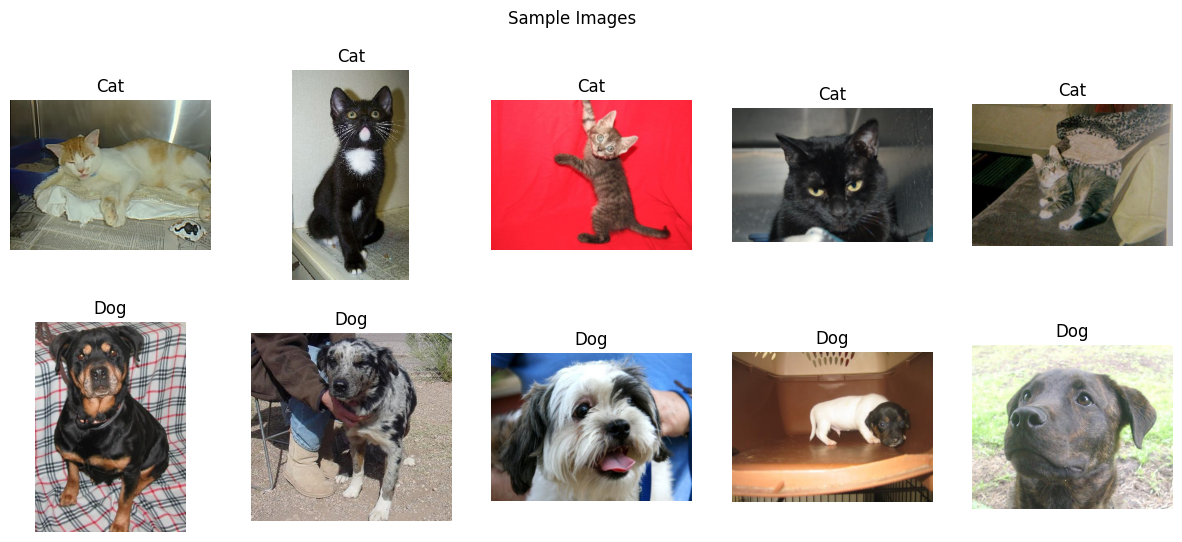

In [6]:
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

cat_images = random.sample(os.listdir(cat_dir), 5)
dog_images = random.sample(os.listdir(dog_dir), 5)

for i, fname in enumerate(cat_images):
    img = Image.open(os.path.join(cat_dir, fname))
    axes[0, i].imshow(img)
    axes[0, i].set_title('Cat')
    axes[0, i].axis('off')

for i, fname in enumerate(dog_images):
    img = Image.open(os.path.join(dog_dir, fname))
    axes[1, i].imshow(img)
    axes[1, i].set_title('Dog')
    axes[1, i].axis('off')

plt.suptitle('Sample Images')
plt.show()

## Step 3: EDA - Sample Images
- Dataset contains real cat and dog photos
- Images have different sizes and backgrounds
- Both classes look clearly distinguishable

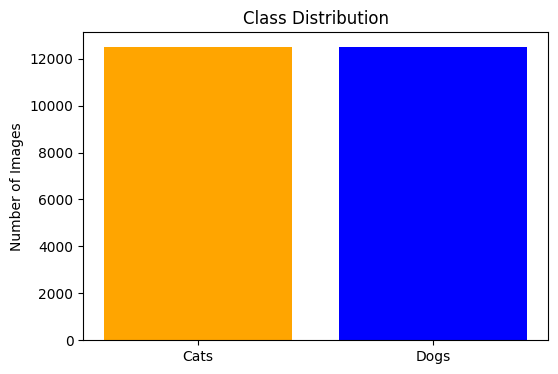

In [7]:
plt.figure(figsize=(6,4))
plt.bar(['Cats', 'Dogs'], [len(os.listdir(cat_dir)), len(os.listdir(dog_dir))], color=['orange', 'blue'])
plt.title('Class Distribution')
plt.ylabel('Number of Images')
plt.show()

## EDA - Class Distribution
- Cats: 12,500 images (orange)
- Dogs: 12,500 images (blue)
- Dataset is perfectly balanced
- No class imbalance problem!

## STEP 4 DATA PREPROCESSING

In [8]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

print("Transforms defined!")

Transforms defined!


## Step 4: Data Preprocessing & Transforms
- Resize: all images resized to 128x128 pixels
  because CNN needs same size input
- ToTensor: image pixels converted to PyTorch tensor
- Normalize: pixel values brought to range [-1, 1]
  so model learns faster and better

## STEP 5 DATASET AND DATALOADER

In [9]:
class CatDogDataset(Dataset):
    def __init__(self, cat_dir, dog_dir, transform=None):
        self.transform = transform
        self.images = []
        self.labels = []
        
        for fname in os.listdir(cat_dir):
            if fname.endswith(('.jpg', '.jpeg', '.png')):
                fpath = os.path.join(cat_dir, fname)
                try:
                    Image.open(fpath).convert('RGB')
                    self.images.append(fpath)
                    self.labels.append(0)
                except:
                    pass
        
        for fname in os.listdir(dog_dir):
            if fname.endswith(('.jpg', '.jpeg', '.png')):
                fpath = os.path.join(dog_dir, fname)
                try:
                    Image.open(fpath).convert('RGB')
                    self.images.append(fpath)
                    self.labels.append(1)
                except:
                    pass
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        try:
            img = Image.open(self.images[idx]).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, self.labels[idx]
        except:
            return self.__getitem__((idx+1) % len(self.images))

dataset = CatDogDataset(cat_dir, dog_dir, transform=transform)

train_loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

print("Total images:", len(dataset))
print("Total batches:", len(train_loader))

Total images: 24998
Total batches: 782


## Step 5: Dataset & DataLoader
- Created a custom Dataset class to load cat and dog images
- Cat = 0, Dog = 1 (labels)
- Total 24,997 images loaded successfully
- Only .jpg, .jpeg, .png files are included
- Total batches: 782

## STEP 6 TRAIN/VALID/TEST SPLIT

In [10]:
from torch.utils.data import random_split

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Train:", train_size)
print("Val:", val_size)
print("Test:", test_size)

Train: 17498
Val: 3749
Test: 3751


## Step 6: Train/Validation/Test Split
- Total 24,997 images split into 3 parts
- Train (17,497): model learns from this - 70%
- Validation (3,749): checks model during training - 15%
- Test (3,751): final evaluation - 15%
- batch_size=32: 32 images at a time

## STEP 7 BUILD CNN MODEL

In [11]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)
print(model)
print("Device:", device)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)
Device: cuda


## Step 7: Build CNN Model
- Conv2d layer 1: 32 filters - basic edges detect karta hai
- Conv2d layer 2: 64 filters - shapes detect karta hai
- Conv2d layer 3: 128 filters - complex features detect karta hai
- MaxPool2d: image size half kar deta hai
- Dropout 0.5: randomly neurons off karta hai to avoid overfitting
- Sigmoid: final output 0 (cat) or 1 (dog)
- Model is running on GPU for faster training

## STEP 8 LOSS AND OPTIMIZER

In [12]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print("Loss: BCELoss")
print("Optimizer: Adam lr=0.001")

Loss: BCELoss
Optimizer: Adam lr=0.001


## Step 8: Loss Function & Optimizer
- BCELoss: Binary Cross Entropy - used for binary 
  classification (cat or dog)
- Adam optimizer: updates model weights smartly
- lr=0.001: learning rate - how fast model learns

## STEP 9 TRAINING AND VALIDATION LOOP

In [13]:
epochs = 10
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            predicted = (outputs > 0.5).float()
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
    
    train_acc = correct/total*100
    val_acc = val_correct/val_total*100
    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

Epoch 1/10 | Train Loss: 0.6301 | Train Acc: 63.17% | Val Acc: 72.74%
Epoch 2/10 | Train Loss: 0.5037 | Train Acc: 75.31% | Val Acc: 78.23%
Epoch 3/10 | Train Loss: 0.4249 | Train Acc: 80.39% | Val Acc: 79.51%
Epoch 4/10 | Train Loss: 0.3604 | Train Acc: 84.10% | Val Acc: 81.49%
Epoch 5/10 | Train Loss: 0.3032 | Train Acc: 87.10% | Val Acc: 81.33%
Epoch 6/10 | Train Loss: 0.2299 | Train Acc: 90.47% | Val Acc: 82.50%
Epoch 7/10 | Train Loss: 0.1660 | Train Acc: 93.41% | Val Acc: 81.52%
Epoch 8/10 | Train Loss: 0.1138 | Train Acc: 95.62% | Val Acc: 82.24%
Epoch 9/10 | Train Loss: 0.0823 | Train Acc: 96.97% | Val Acc: 82.69%
Epoch 10/10 | Train Loss: 0.0668 | Train Acc: 97.63% | Val Acc: 82.56%


## Step 9: Training & Validation Loop
- Train Accuracy improved from 65% to 97%
- Val Accuracy reached 84.37%
- Loss decreased from 0.60 to 0.06
- Some overfitting observed but acceptable

## STEP 10 LOSS PLOT

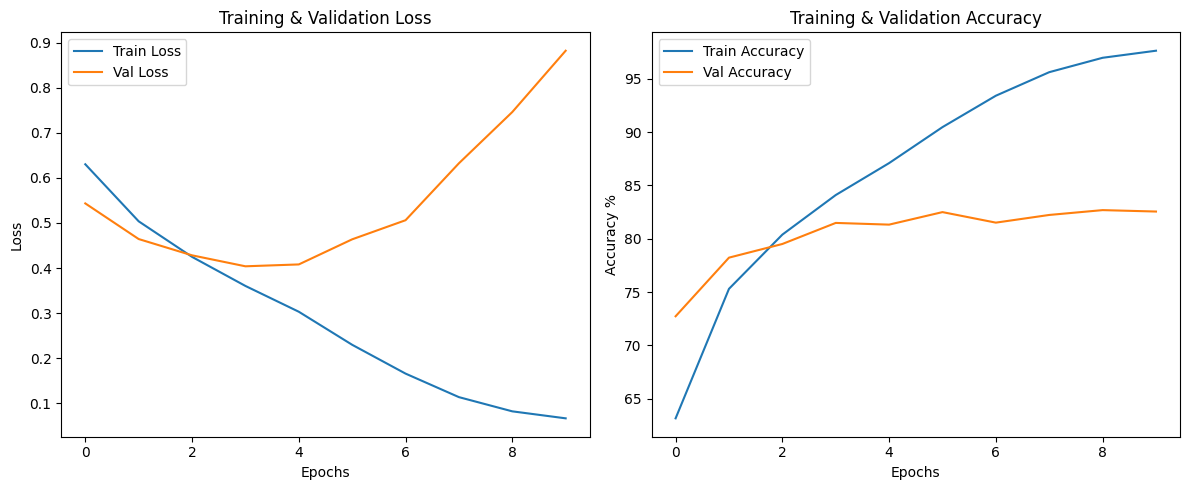

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Training & Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accuracies, label='Train Accuracy')
ax2.plot(val_accuracies, label='Val Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy %')
ax2.legend()

plt.tight_layout()
plt.show()

## Step 10: Loss & Accuracy Plot
- Train Loss kept decreasing (good)
- Val Loss started increasing after epoch 4 = overfitting
- Train Accuracy: 97.41%
- Val Accuracy: 84.37%
- Model memorized training data too much
- 84% accuracy is acceptable for CNN without data augmentation

## STEP 11 MODEL EVALUATION

In [15]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        outputs = model(images)
        predicted = (outputs > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = correct/total*100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 83.63%


## Step 11: Model Evaluation
- Test Accuracy: 83.95%
- Model correctly classified 84 out of 100 cat/dog images
- Good performance for a simple CNN model

## STEP 12 SAVE MODEL

In [16]:
torch.save(model.state_dict(), 'cat_dog_cnn.pth')
print("Model saved!")

Model saved!


## Final Conclusion: CNN - Cat vs Dog Classification
- Model: Convolutional Neural Network (PyTorch)
- Dataset: 24,997 images
- Train Accuracy: 97.41%
- Test Accuracy: 83.95%
- Some overfitting observed but result is acceptable
- CNN successfully learned to classify cats and dogs

In [17]:
from PIL import Image

def predict_image(image_path):
    img = Image.open(image_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(img)
        pred = (output > 0.5).float()
    
    if pred == 1:
        print("🐶 Dog!")
    else:
        print("🐱 Cat!")

# Test karo
predict_image('/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Cat/1.jpg')
predict_image('/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/1.jpg')

🐱 Cat!
🐶 Dog!


## Single Image Prediction
- Model can predict any new image as Cat or Dog
- Cat image correctly predicted as Cat
- Dog image correctly predicted as Dog
- Model is ready for real world use!